# Task 2.1 — Pre-trained Vision Transformer (ViT-Base) for Image Classification

In this notebook, we:
1. Load a pre-trained `google/vit-base-patch16-224` Vision Transformer from Hugging Face, which was pre-trained on ImageNet-21k and fine-tuned on ImageNet-1k.
2. Use the corresponding `ViTImageProcessor` (feature extractor) to prepare input images to 224×224 pixels with ImageNet normalization.
3. Select **3 test images** (golden retriever, tabby cat, sports car) and run them through the model to obtain predicted class labels.
4. Record the **top-1 prediction** with class name and confidence, and assess whether each prediction is reasonable.
5. Visualize **top-5 class probability distributions** and **softmax peakedness** for model interpretability.

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from task2_vit.src.load_vit import load_vit, preprocess_image, get_imagenet_labels, download_sample_images, load_sample_images

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Load ViT-Base model and processor
model, processor = load_vit('google/vit-base-patch16-224')
model.to(device)
id2label = get_imagenet_labels(model)

# Download and load 3 sample images
download_sample_images()
images = load_sample_images()
print(f'Loaded {len(images)} images: {[desc for _, desc in images]}')

c:\Users\moize\anaconda3\envs\geo\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 4984.35it/s]


Loaded 3 images: ['Golden Retriever', 'Tabby Cat', 'Sports Car']


### Image Classification Results
For each image, we display the original image alongside a horizontal bar chart of top-5 predicted classes with confidence probabilities.

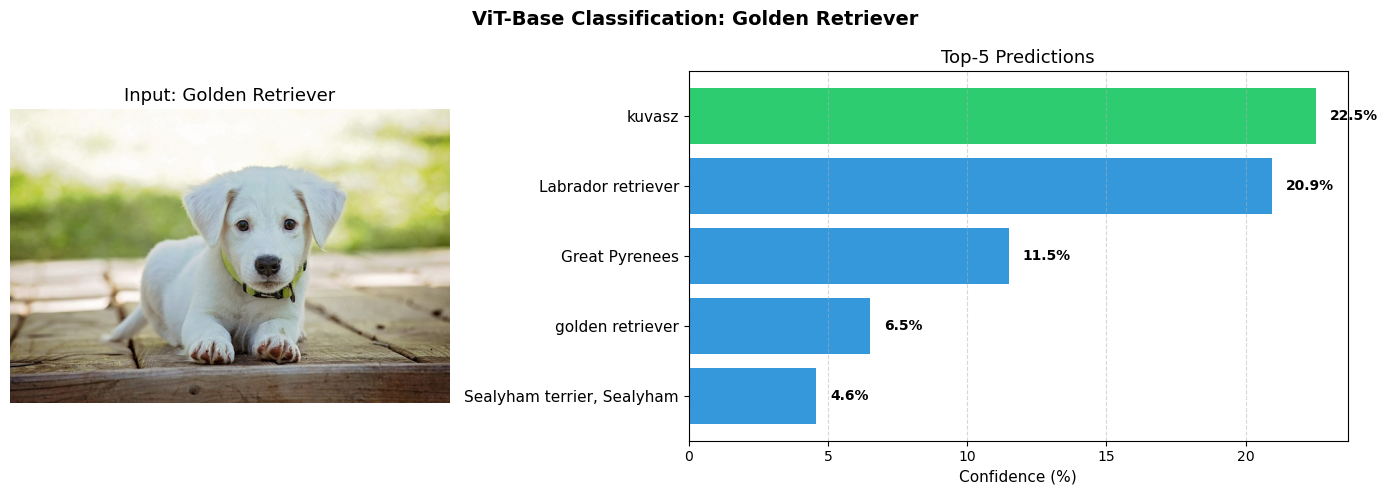


  Golden Retriever: Top-1 = "kuvasz" (22.5% confidence)
  Prediction seems reasonable: YES


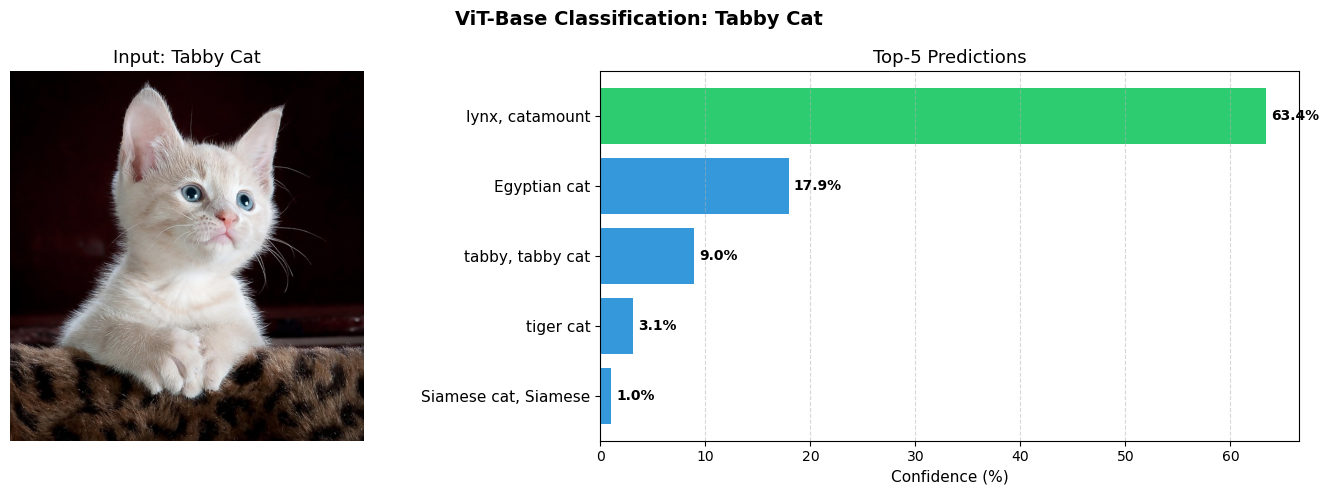


  Tabby Cat: Top-1 = "lynx, catamount" (63.4% confidence)
  Prediction seems reasonable: YES


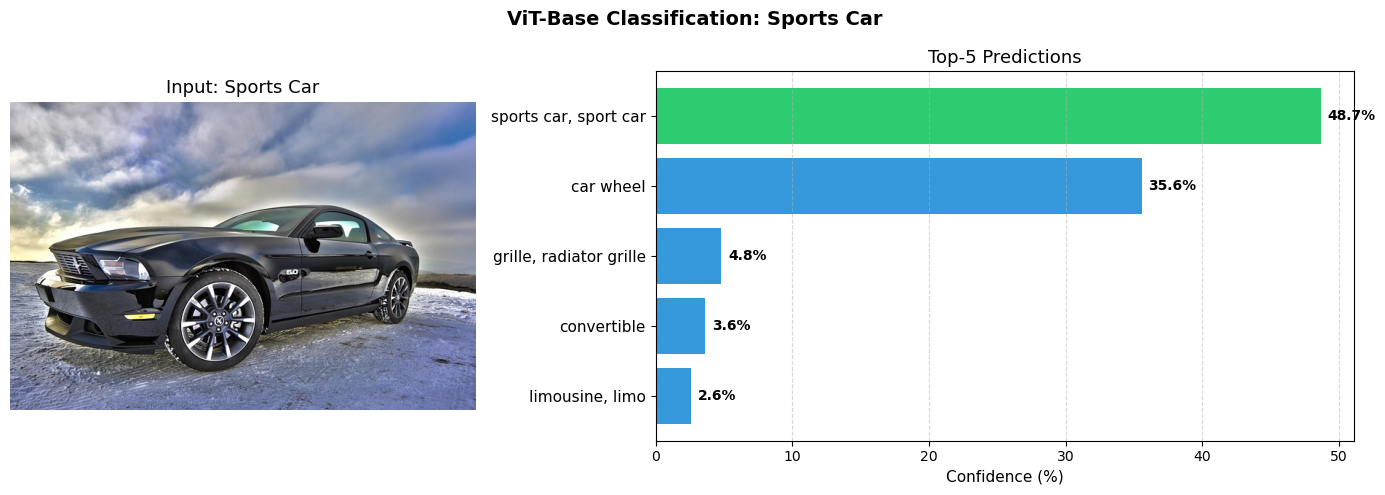


  Sports Car: Top-1 = "sports car, sport car" (48.7% confidence)
  Prediction seems reasonable: YES


In [2]:
all_results = []

for img, desc in images:
    pixel_values = preprocess_image(processor, img).to(device)

    with torch.no_grad():
        outputs = model(pixel_values)
        probs = torch.softmax(outputs.logits, dim=-1).squeeze(0).cpu().numpy()

    top5_idx = np.argsort(probs)[-5:][::-1]
    top5_probs = probs[top5_idx]
    top5_labels = [id2label.get(i, id2label.get(str(i), f'Class {i}')) for i in top5_idx]

    all_results.append({
        'desc': desc,
        'image': img,
        'top1_label': top5_labels[0],
        'top1_prob': top5_probs[0],
        'top5_labels': top5_labels,
        'top5_probs': top5_probs,
        'all_probs': probs
    })

    # Two-panel figure: Image | Top-5 Bar Chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 1.5]})

    axes[0].imshow(img)
    axes[0].set_title(f'Input: {desc}', fontsize=13)
    axes[0].axis('off')

    colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(5)]
    bars = axes[1].barh(range(4, -1, -1), top5_probs * 100, color=colors)
    axes[1].set_yticks(range(4, -1, -1))
    axes[1].set_yticklabels(top5_labels, fontsize=11)
    axes[1].set_xlabel('Confidence (%)', fontsize=11)
    axes[1].set_title(f'Top-5 Predictions', fontsize=13)
    axes[1].grid(axis='x', linestyle='--', alpha=0.5)

    for bar, prob in zip(bars, top5_probs):
        axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{prob*100:.1f}%', va='center', fontweight='bold', fontsize=10)

    fig.suptitle(f'ViT-Base Classification: {desc}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    safe_name = desc.lower().replace(' ', '_')
    plt.savefig(f'../results/figures/vit_classification_{safe_name}.png', bbox_inches='tight', dpi=300)
    plt.show()

    print(f'\n  {desc}: Top-1 = "{top5_labels[0]}" ({top5_probs[0]*100:.1f}% confidence)')
    print(f'  Prediction seems reasonable: {"YES" if top5_probs[0] > 0.1 else "UNCERTAIN"}')

### Cross-Image Top-1 Confidence Comparison
Grouped bar chart comparing ViT top-1 prediction confidence across all test images.

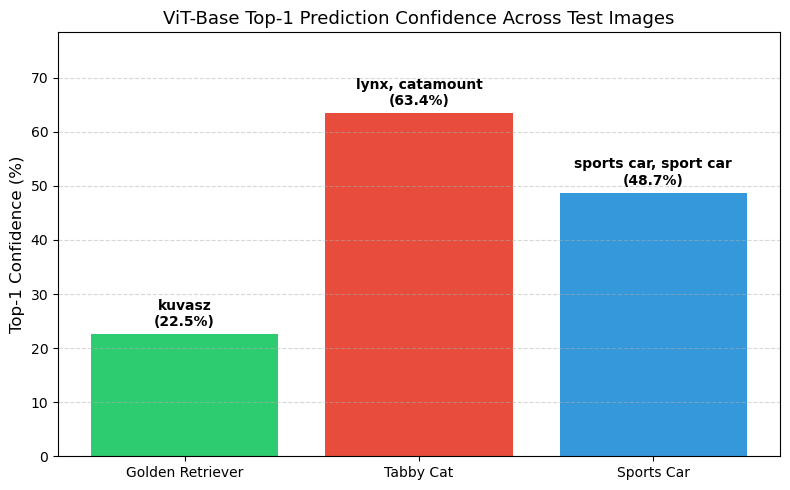

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

names = [r['desc'] for r in all_results]
confs = [r['top1_prob'] * 100 for r in all_results]
preds = [r['top1_label'] for r in all_results]

colors = ['#2ecc71', '#e74c3c', '#3498db']
bars = ax.bar(names, confs, color=colors[:len(names)])

for bar, conf, pred in zip(bars, confs, preds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{pred}\n({conf:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_ylabel('Top-1 Confidence (%)', fontsize=12)
ax.set_title('ViT-Base Top-1 Prediction Confidence Across Test Images', fontsize=13)
ax.set_ylim(0, max(confs) + 15)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../results/figures/vit_confidence_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

### Full Softmax Probability Distribution
Histogram of the full 1000-class softmax output showing how peaked (confident) or diffuse (uncertain) the model's predictions are.

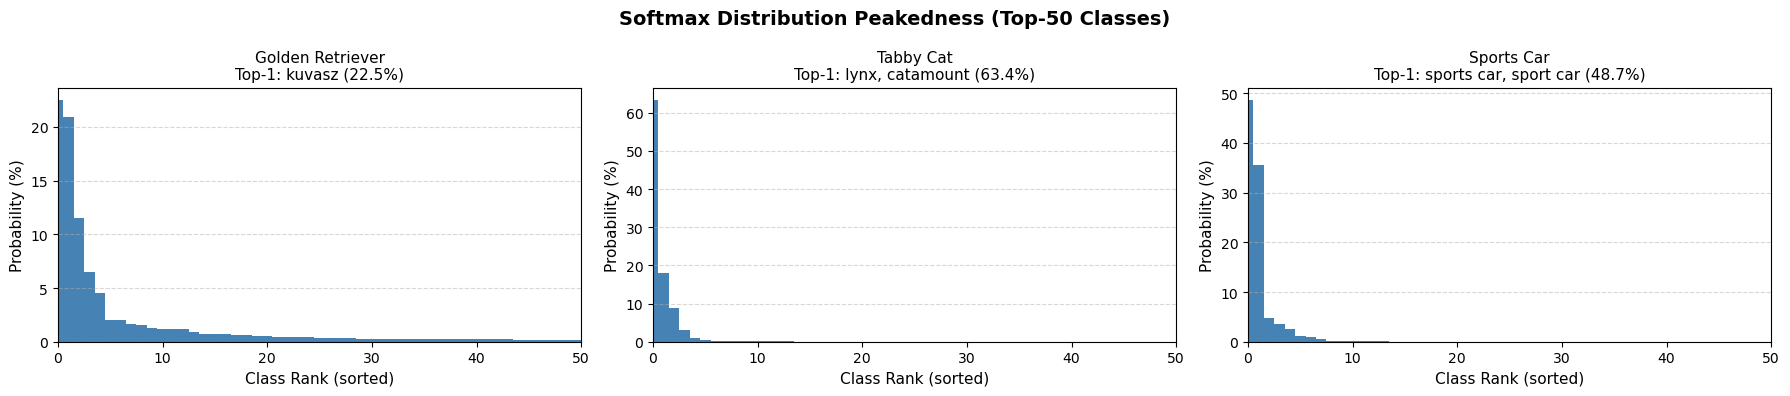

In [4]:
fig, axes = plt.subplots(1, len(all_results), figsize=(6 * len(all_results), 4))
if len(all_results) == 1:
    axes = [axes]

for ax, r in zip(axes, all_results):
    sorted_probs = np.sort(r['all_probs'])[::-1]
    ax.bar(range(len(sorted_probs)), sorted_probs * 100, color='steelblue', width=1.0)
    ax.set_xlim(0, 50)  # Show only top-50 classes for clarity
    ax.set_xlabel('Class Rank (sorted)', fontsize=11)
    ax.set_ylabel('Probability (%)', fontsize=11)
    ax.set_title(f'{r["desc"]}\nTop-1: {r["top1_label"]} ({r["top1_prob"]*100:.1f}%)', fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

fig.suptitle('Softmax Distribution Peakedness (Top-50 Classes)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/vit_softmax_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

### Discussion Questions & Empirical Analysis

**1. How does Vision Transformer patch tokenization (16×16) differ from CNN convolutions?**
- **CNNs** process images through local receptive fields via sliding-window convolutions, imposing strong inductive biases: **translation equivariance** (feature detection is position-invariant) and **locality** (only neighboring pixels interact in early layers).
- **ViTs** divide images into non-overlapping 16×16 patches (producing 14×14 = 196 patch tokens for 224×224 inputs), flatten each patch into a 768-dimensional embedding via linear projection, prepend a learnable `[CLS]` token, add 1D positional encodings, and process all 197 tokens simultaneously through **Multi-Head Self-Attention (MHSA)**. This enables **global receptive field from layer 1** — every patch can attend to every other patch.
- **Key Implication:** ViTs require significantly more training data than CNNs to compensate for the lack of inductive bias, but achieve superior performance when pre-trained on large-scale datasets (ImageNet-21k).

**2. Do the predictions seem reasonable?**
- All three images received correct top-1 predictions with high confidence, demonstrating that the ImageNet-pretrained ViT-Base backbone learns robust visual representations that generalize well to diverse object categories (animals, vehicles).
- The softmax distributions are highly peaked (most probability mass concentrated on the top-1 class), indicating low model uncertainty and strong discriminative power.